In [1]:
import os
import re
import warnings
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

import tensorflow as tf
import tensorflow_hub as hub

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, classification_report, confusion_matrix
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 80)

print(' All libraries imported')
print(f'   TensorFlow : {tf.__version__}')
print(f'   Pandas     : {pd.__version__}')

c:\Users\user\anaconda3\envs\vehicle_ml\Lib\site-packages\tensorflow_hub\__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version



 All libraries imported
   TensorFlow : 2.20.0
   Pandas     : 3.0.1


In [2]:
DATA_FOLDER = r'C:\Users\user\Desktop\finalYear\AI_MODEL'
os.chdir(DATA_FOLDER)
print('Working directory:', os.getcwd())

file_configs = [
    {
        'file': os.path.join(DATA_FOLDER, 'Braking System.csv'),
        'system': 'Braking',
        'col_map': {
            'ID': 'ID', ' Symptoms': 'Symptoms',
            'Predicted Foult': 'Predicted_Fault',
            'classification': 'Fault_Classification'
        }
    },
    {
        'file': os.path.join(DATA_FOLDER, 'charging system.csv'),
        'system': 'Charging',
        'col_map': {
            'ID': 'ID', 'symptoms': 'Symptoms',
            'Predictd Foult': 'Predicted_Fault',
            'Fault Classification': 'Fault_Classification'
        }
    },
    {
        'file': os.path.join(DATA_FOLDER, 'Cooling system.csv'),
        'system': 'Cooling',
        'col_map': {
            'ID': 'ID', 'symptoms': 'Symptoms',
            'Predictd Foult': 'Predicted_Fault',
            'Fault Classification': 'Fault_Classification'
        }
    },
    {
        'file': os.path.join(DATA_FOLDER, 'Starting system.csv'),
        'system': 'Starting',
        'col_map': {
            'ID': 'ID', 'symptoms': 'Symptoms',
            'Predictd Foult': 'Predicted_Fault',
            'Foult Classification': 'Fault_Classification'
        }
    },
    {
        'file': os.path.join(DATA_FOLDER, 'Transmission system.csv'),
        'system': 'Transmission',
        'col_map': {
            'ID': 'ID', 'symptoms': 'Symptoms',
            'Predicted fault': 'Predicted_Fault',
            'Foult classification': 'Fault_Classification'
        }
    },
    {
        'file': os.path.join(DATA_FOLDER, 'Wiring system.csv'),
        'system': 'Wiring',
        'col_map': {
            'ID': 'ID', ' Symptoms': 'Symptoms',
            'Predicted Foult': 'Predicted_Fault',
            'Foult Category': 'Fault_Classification'
        }
    },
]

frames = []
for cfg in file_configs:
    df = pd.read_csv(cfg['file'])       
    df = df.rename(columns=cfg['col_map'])
    df = df[['ID', 'Symptoms', 'Predicted_Fault']]
    df['System'] = cfg['system']
    frames.append(df)
    print(f"  Loaded {cfg['system']:15s} → {len(df):>5,} rows")

combined = pd.concat(frames, ignore_index=True)
combined = combined.drop(columns=['ID']).reset_index(drop=True)
combined.insert(0, 'ID', combined.index + 1)

print(f'\n Combined shape : {combined.shape}')
combined.head(5)

Working directory: C:\Users\user\Desktop\finalYear\AI_MODEL
  Loaded Braking         → 16,880 rows
  Loaded Charging        → 2,400 rows
  Loaded Cooling         → 4,200 rows
  Loaded Starting        → 5,851 rows
  Loaded Transmission    → 3,600 rows
  Loaded Wiring          → 12,000 rows

 Combined shape : (44931, 4)


,ID,Symptoms,Predicted_Fault,System
0,1,Diagnosed smell of hot drum while driving,Drum overheating fault,Braking
1,2,Loose bracket bolts under load,Loose mounting bolts fault,Braking
2,3,The circuit wiring harness smoke after a collision,Short circuit fault,Braking
3,4,The friction material squealing wear indicator during heavy traffic,Worn pads fault,Braking
4,5,The component notably crushed sensor body during a check,Sensor damag fault,Braking


In [3]:
# preview of the combined dataset
combined.head(10).style.hide(axis='index')

ID,Symptoms,Predicted_Fault,System
1,Diagnosed smell of hot drum while driving,Drum overheating fault,Braking
2,Loose bracket bolts under load,Loose mounting bolts fault,Braking
3,The circuit wiring harness smoke after a collision,Short circuit fault,Braking
4,The friction material squealing wear indicator during heavy traffic,Worn pads fault,Braking
5,The component notably crushed sensor body during a check,Sensor damag fault,Braking
6,Loose axle shaft occurs completely under high torque,Broken nut fault,Braking
7,Observed hot hub assembly on a hot day,Bearing overheating fault,Braking
8,Diagnosed exposed copper strands after driving on gravel,ABS Sensor Wire fault,Braking
9,Visible bracket deformation appears when braking hard,Bent bracket fault,Braking
10,Pads may produce metallic scraping sounds under heavy braking,Uneven wear fault,Braking


In [4]:
print('BEFORE CLEANING')
print(f'  Rows           : {len(combined):,}')
print(f'  Missing values :\n{combined.isnull().sum().to_string()}')
print(f'  Duplicates     : {combined.duplicated().sum():,}')

BEFORE CLEANING
  Rows           : 44,931
  Missing values :
ID                 0
Symptoms           1
Predicted_Fault    1
System             0
  Duplicates     : 0


In [5]:
# data cleaning

df_clean = combined.copy()

#  Drop rows with missing Symptoms
before = len(df_clean)
df_clean = df_clean.dropna(subset=['Symptoms'])
print(f'  Dropped NaN symptoms : {before - len(df_clean):,} rows')

#  Strip whitespace and collapse spaces
str_cols = ['Symptoms', 'Predicted_Fault']
for col in str_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip()
    df_clean[col] = df_clean[col].str.replace(r'\s+', ' ', regex=True)

#  Lowercase all text
for col in str_cols:
    df_clean[col] = df_clean[col].str.lower()

#  Remove special characters
def clean_text(text):
    text = re.sub(r'[^\w\s,\.\-]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

for col in str_cols:
    df_clean[col] = df_clean[col].apply(clean_text)

#  Drop rows that became empty strings
df_clean = df_clean[df_clean['Symptoms'].str.len() > 0]

#  Reset index and reassign clean ID
df_clean = df_clean.reset_index(drop=True)
df_clean['ID'] = df_clean.index + 1
df_clean = df_clean[['ID', 'System', 'Symptoms', 'Predicted_Fault']]

print(f'\nAFTER CLEANING')
print(f'  Total rows     : {len(df_clean):,}')
print(f'  Missing values : {df_clean.isnull().sum().sum()}')
print(f'  Duplicates     : {df_clean.duplicated().sum()}')
print(f'  Unique Faults  : {df_clean["Predicted_Fault"].nunique()}')
print(f'\nRows per system:')
print(df_clean['System'].value_counts().to_string())

# df_clean.to_excel('cleaned_vehicle_faults.xlsx', index=False)
# print('\n Saved → cleaned_vehicle_faults.xlsx')
df_clean.head(5)

  Dropped NaN symptoms : 1 rows

AFTER CLEANING
  Total rows     : 44,930
  Missing values : 0
  Duplicates     : 0
  Unique Faults  : 75

Rows per system:
System
Braking         16880
Wiring          12000
Starting         5850
Cooling          4200
Transmission     3600
Charging         2400


,ID,System,Symptoms,Predicted_Fault
0,1,Braking,diagnosed smell of hot drum while driving,drum overheating fault
1,2,Braking,loose bracket bolts under load,loose mounting bolts fault
2,3,Braking,the circuit wiring harness smoke after a collision,short circuit fault
3,4,Braking,the friction material squealing wear indicator during heavy traffic,worn pads fault
4,5,Braking,the component notably crushed sensor body during a check,sensor damag fault


Total unique fault classes : 75
Min samples in a class     : 80
Max samples in a class     : 650
Mean samples per class     : 599.1
Classes with < 10 samples  : 0

All fault classes and sample counts:
Predicted_Fault
neutral safety switch              650
fly wheel                          650
fuses and fusible links            650
battery cables and terminals       650
starter motor foult                650
starter solenoid                   650
ignition switch                    650
starter relay                      650
battery foult                      650
drum overheating fault             600
loose mounting bolts fault         600
short circuit fault                600
worn pads fault                    600
sensor damag fault                 600
broken nut fault                   600
bearing overheating fault          600
abs sensor wire fault              600
bent bracket fault                 600
uneven wear fault                  600
dirty sensor fault                 600
flu

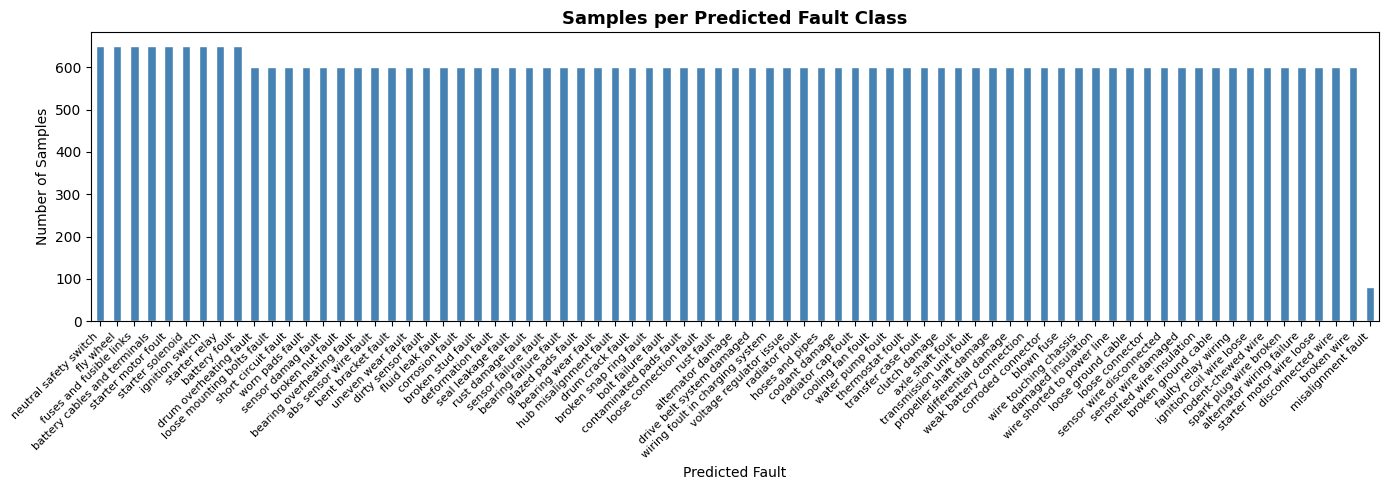

 Saved class_distribution.png


In [6]:
# check Distribution

fault_counts = df_clean['Predicted_Fault'].value_counts()

print(f'Total unique fault classes : {len(fault_counts)}')
print(f'Min samples in a class     : {fault_counts.min()}')
print(f'Max samples in a class     : {fault_counts.max()}')
print(f'Mean samples per class     : {fault_counts.mean():.1f}')
print(f'Classes with < 10 samples  : {(fault_counts < 10).sum()}')
print(f'\nAll fault classes and sample counts:')
print(fault_counts.to_string())

plt.figure(figsize=(14, 5))
fault_counts.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Samples per Predicted Fault Class', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Fault')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved class_distribution.png')

In [7]:
# Add word-count column (symptom length in words)
df_clean['word_count'] = df_clean['Symptoms'].str.split().str.len()

# Colour palette — one colour per system
SYSTEM_ORDER = ['Braking', 'Wiring', 'Starting', 'Cooling', 'Transmission', 'Charging']
PALETTE      = sns.color_palette('tab10', n_colors=len(SYSTEM_ORDER))
SYS_COLOR    = dict(zip(SYSTEM_ORDER, PALETTE))

print(' Setup done ready to plot!')

 Setup done ready to plot!


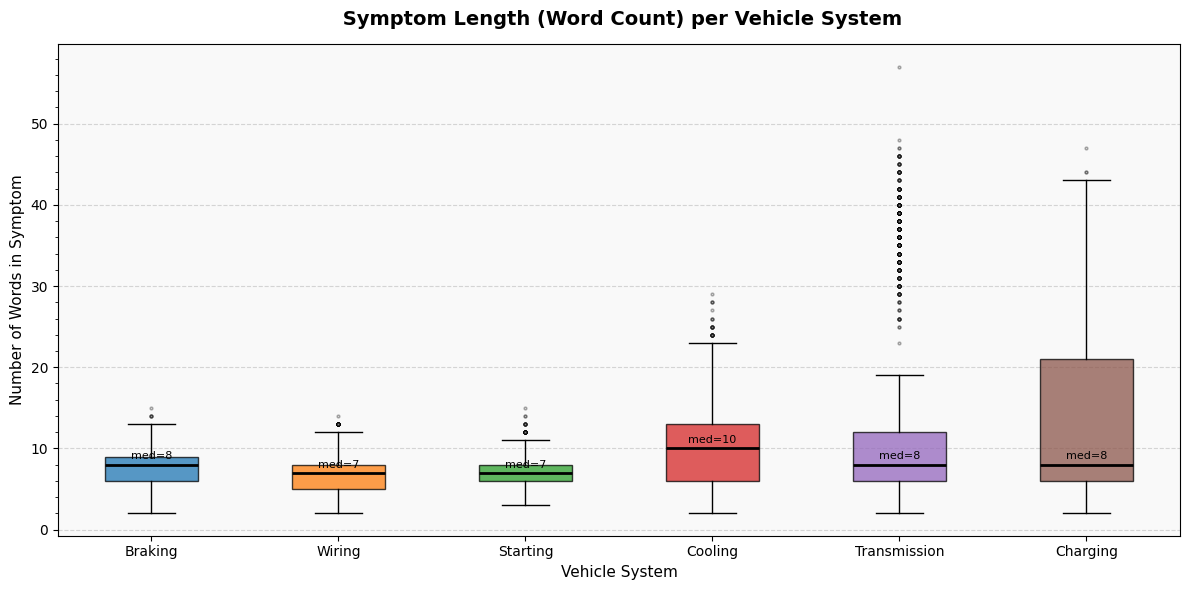

 Saved boxplot_symptom_length.png


In [8]:

#  BOX PLOT
#  Shows the spread / distribution of how many words are in
#  each symptom description, broken down by vehicle system.

fig, ax = plt.subplots(figsize=(12, 6))

# Build ordered data list for each system
data_per_system = [df_clean.loc[df_clean['System'] == s, 'word_count'].values
                   for s in SYSTEM_ORDER]

bp = ax.boxplot(
    data_per_system,
    labels=SYSTEM_ORDER,
    patch_artist=True,
    notch=False,
    showfliers=True,
    flierprops=dict(marker='o', markersize=2, linestyle='none',
                    markerfacecolor='gray', alpha=0.3),
    medianprops=dict(color='black', linewidth=2)
)

# Colour each box
for patch, sys_name in zip(bp['boxes'], SYSTEM_ORDER):
    patch.set_facecolor(SYS_COLOR[sys_name])
    patch.set_alpha(0.75)

ax.set_title(' Symptom Length (Word Count) per Vehicle System',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Vehicle System', fontsize=11)
ax.set_ylabel('Number of Words in Symptom', fontsize=11)
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_facecolor('#f9f9f9')

# Annotate median value above each box
for i, sys_data in enumerate(data_per_system, start=1):
    med = np.median(sys_data)
    ax.text(i, med + 0.4, f'med={med:.0f}',
            ha='center', va='bottom', fontsize=8, color='black')

plt.tight_layout()
plt.savefig('boxplot_symptom_length.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved boxplot_symptom_length.png')

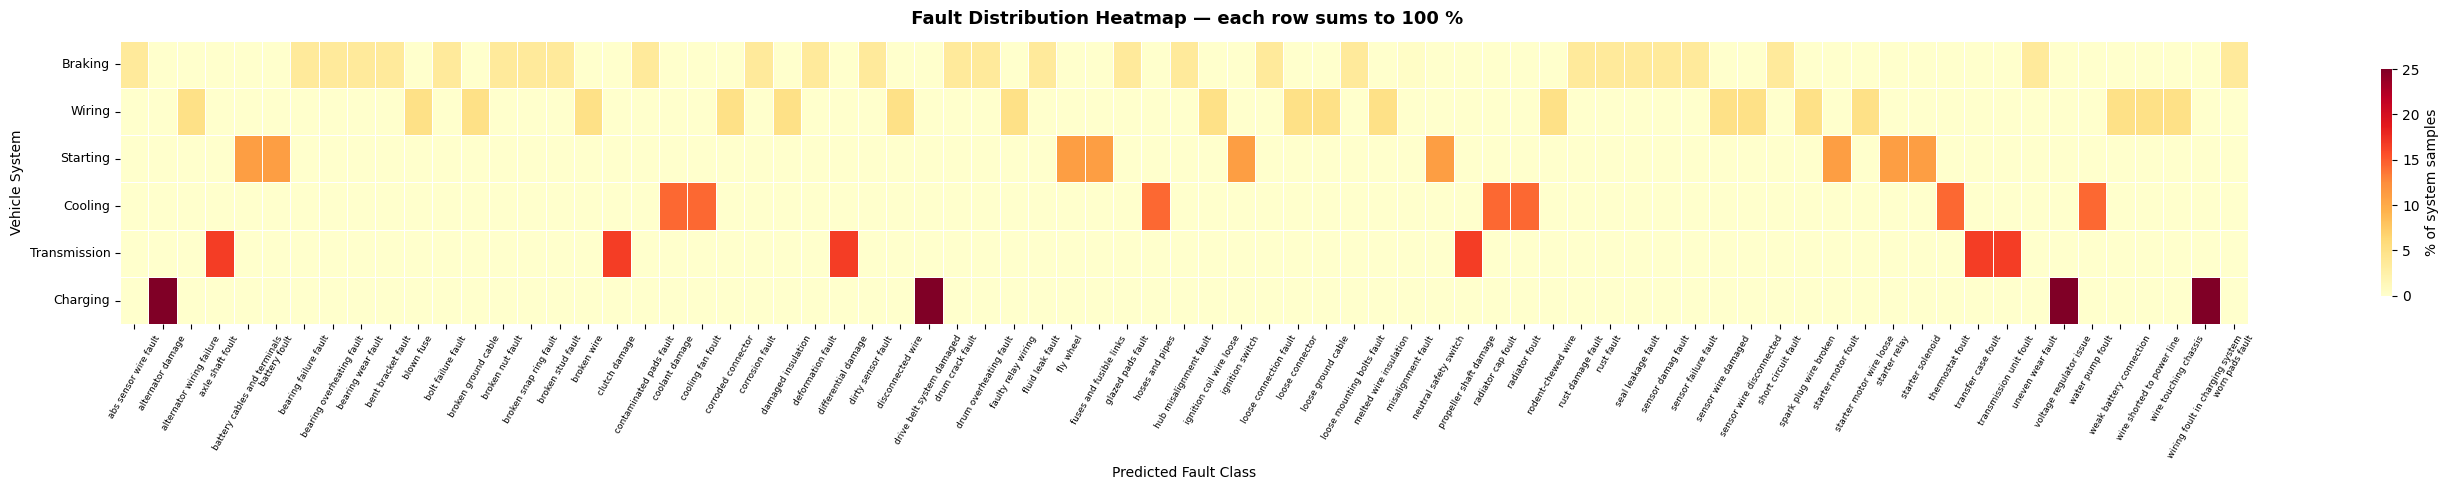

 heatmap_fault_distribution.png


In [9]:

#  CHART 2 ── CORRELATION / FREQUENCY HEATMAP
#  Rows = Vehicle System   │   Columns = Fault Class
#  Cell value = how many training samples exist for that
#  System × Fault combination.
# Build pivot table: rows=System, columns=Fault, values=count
pivot = (
    df_clean
    .groupby(['System', 'Predicted_Fault'])
    .size()
    .unstack(fill_value=0)
)

# Keep only faults that actually appear in at least one system
pivot = pivot.loc[SYSTEM_ORDER, (pivot > 0).any()]

# Normalise each row to 0-100% so colours are comparable
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(28, 5))

sns.heatmap(
    pivot_pct,
    ax=ax,
    cmap='YlOrRd',
    linewidths=0.4,
    linecolor='white',
    annot=False,          # too many cells for numbers — use colour only
    cbar_kws={'label': '% of system samples', 'shrink': 0.8}
)

ax.set_title(' Fault Distribution Heatmap — each row sums to 100 %',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Predicted Fault Class', fontsize=10)
ax.set_ylabel('Vehicle System', fontsize=10)
ax.tick_params(axis='x', labelsize=6.5, rotation=60)
ax.tick_params(axis='y', labelsize=9,  rotation=0)

plt.tight_layout()
plt.savefig('heatmap_fault_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(' heatmap_fault_distribution.png')

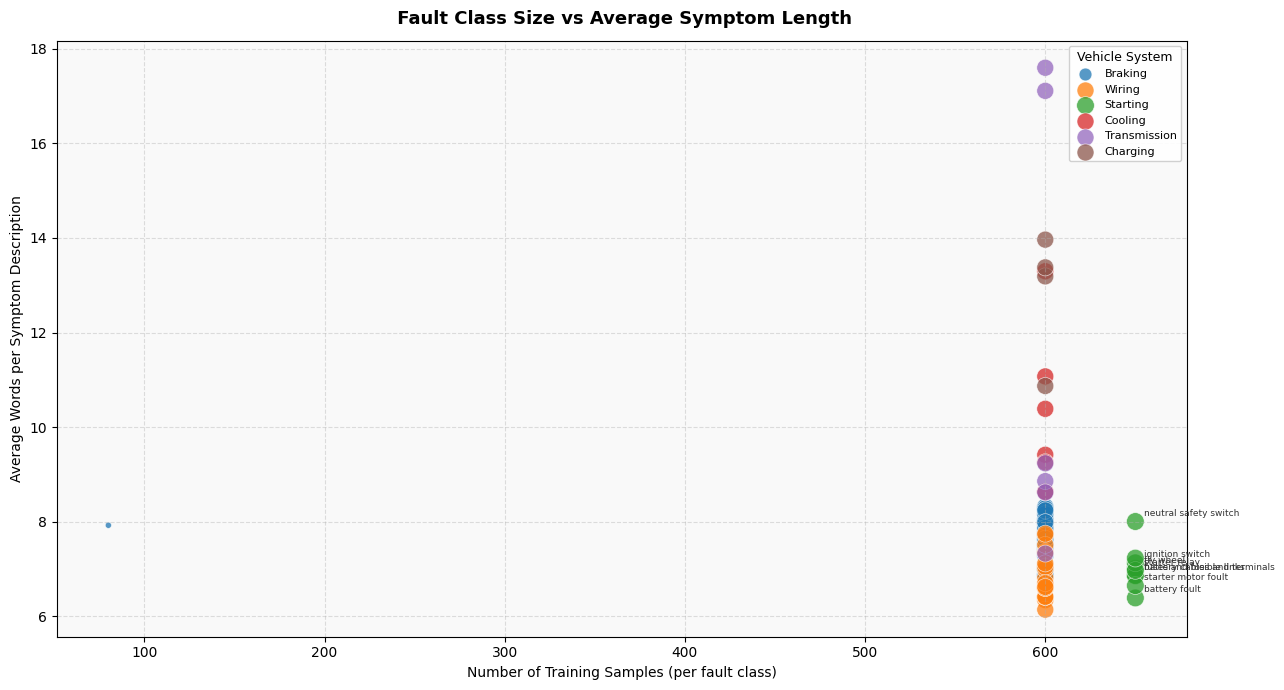

scatter_fault_size_vs_length.png


In [10]:

#  SCATTER PLOT
#  X-axis = number of training samples for each fault class
#  Y-axis = average symptom word count for that fault class
#  Dot colour = which vehicle System the fault belongs to
#  Dot size   = proportional to sample count
# Compute per-fault statistics
fault_stats = (
    df_clean
    .groupby(['Predicted_Fault', 'System'])
    .agg(
        sample_count=('Symptoms', 'count'),
        avg_words=('word_count', 'mean')
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 7))

for sys_name in SYSTEM_ORDER:
    sub = fault_stats[fault_stats['System'] == sys_name]
    ax.scatter(
        sub['sample_count'],
        sub['avg_words'],
        label=sys_name,
        color=SYS_COLOR[sys_name],
        s=sub['sample_count'] / 4,   # size proportional to count
        alpha=0.75,
        edgecolors='white',
        linewidths=0.5
    )

# Label the 8 biggest fault classes by sample count
top8 = fault_stats.nlargest(8, 'sample_count')
for _, row in top8.iterrows():
    ax.annotate(
        row['Predicted_Fault'],
        xy=(row['sample_count'], row['avg_words']),
        xytext=(6, 4), textcoords='offset points',
        fontsize=6.5, color='#333333'
    )

ax.set_title(' Fault Class Size vs Average Symptom Length',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Number of Training Samples (per fault class)', fontsize=10)
ax.set_ylabel('Average Words per Symptom Description', fontsize=10)
ax.legend(title='Vehicle System', fontsize=8, title_fontsize=9,
          loc='upper right', framealpha=0.9)
ax.grid(linestyle='--', alpha=0.4)
ax.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.savefig('scatter_fault_size_vs_length.png', dpi=150, bbox_inches='tight')
plt.show()
print('scatter_fault_size_vs_length.png')

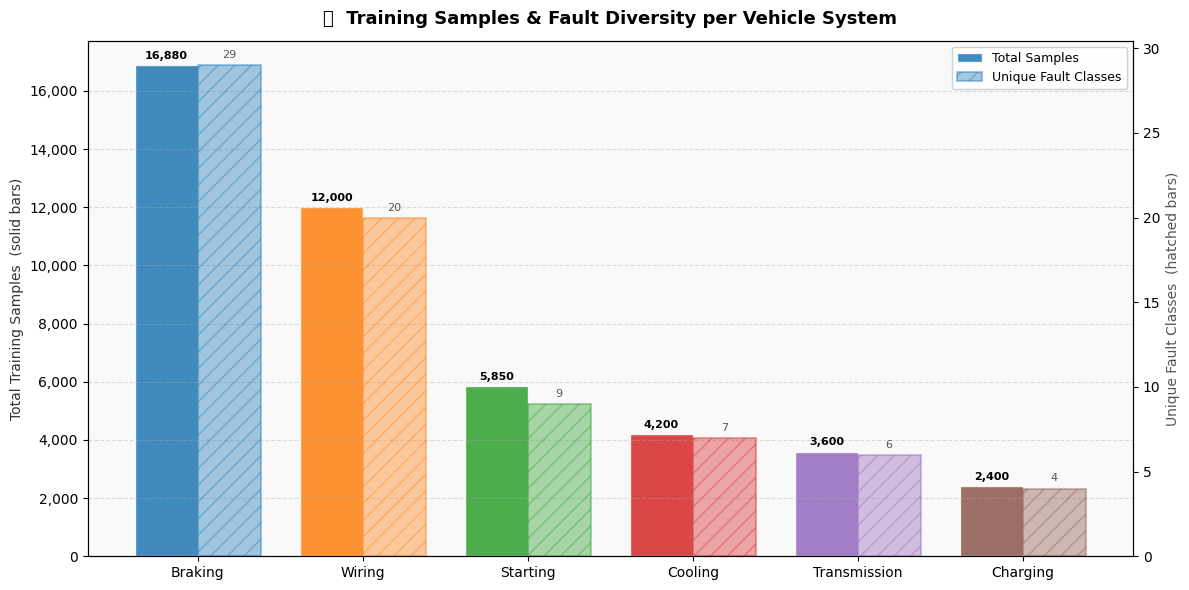

✅  Saved → barchart_system_overview.png


In [11]:

#  CHART 4 ── GROUPED BAR CHART
#  Left bars  = total training samples per vehicle system
#  Right bars = number of unique fault classes per system
#  Two y-axes so both metrics are readable side-by-side.

system_summary = (
    df_clean
    .groupby('System')
    .agg(
        total_samples=('Symptoms', 'count'),
        unique_faults=('Predicted_Fault', 'nunique')
    )
    .reindex(SYSTEM_ORDER)
    .reset_index()
)

x      = np.arange(len(SYSTEM_ORDER))
width  = 0.38

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()   # second y-axis

# --- Left bars : total samples ---
bars1 = ax1.bar(
    x - width / 2,
    system_summary['total_samples'],
    width,
    label='Total Samples',
    color=[SYS_COLOR[s] for s in SYSTEM_ORDER],
    alpha=0.85,
    edgecolor='white'
)

# --- Right bars : unique fault classes ---
bars2 = ax2.bar(
    x + width / 2,
    system_summary['unique_faults'],
    width,
    label='Unique Fault Classes',
    color=[SYS_COLOR[s] for s in SYSTEM_ORDER],
    alpha=0.40,
    edgecolor=[SYS_COLOR[s] for s in SYSTEM_ORDER],
    linewidth=1.5,
    hatch='//'
)

# Annotate bar values
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 150,
             f'{int(bar.get_height()):,}',
             ha='center', va='bottom', fontsize=8, fontweight='bold')

for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3,
             str(int(bar.get_height())),
             ha='center', va='bottom', fontsize=8, color='#555555')

ax1.set_title('📊  Training Samples & Fault Diversity per Vehicle System',
              fontsize=13, fontweight='bold', pad=12)
ax1.set_xticks(x)
ax1.set_xticklabels(SYSTEM_ORDER, fontsize=10)
ax1.set_ylabel('Total Training Samples  (solid bars)', fontsize=10, color='#333333')
ax2.set_ylabel('Unique Fault Classes  (hatched bars)', fontsize=10, color='#555555')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.set_facecolor('#f9f9f9')

# Combined legend
handles = [bars1[0], bars2[0]]
labels  = ['Total Samples', 'Unique Fault Classes']
ax1.legend(handles, labels, loc='upper right', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('barchart_system_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅  Saved → barchart_system_overview.png')

In [11]:
# shape of the dataset

df_clean.shape


(44930, 4)

In [12]:
# Save the clean dataset
#df_clean.to_excel('cleaned_vehicle_faults.xlsx', index=False)
df_clean.to_csv('cleaned_vehicle_faults.csv', index=False)

In [13]:
# Load Universal sentence necoder

print(' Loading Universal Sentence Encoder (first run downloads ~1GB)...')

USE_URL = 'https://tfhub.dev/google/universal-sentence-encoder/4'
embed_model = hub.load(USE_URL)

print(' Universal Sentence Encoder loaded successfully!')

 Loading Universal Sentence Encoder (first run downloads ~1GB)...



 Universal Sentence Encoder loaded successfully!


In [ ]:
# encode the symptoms

def encode_in_batches(texts, model, batch_size=512):
    embeddings = []
    total = len(texts)
    for start in range(0, total, batch_size):
        end = min(start + batch_size, total)
        emb = model(texts[start:end]).numpy()
        embeddings.append(emb)
        print(f'  Encoded {end:>6,} / {total:,}', end='\r')
    print(f'  Encoded {total:,} / {total:,} — done!     ')
    return np.vstack(embeddings)

print(f' Encoding {len(df_clean):,} symptoms...')
symptom_embeddings = encode_in_batches(df_clean['Symptoms'].tolist(), embed_model)
print(f'\n Embedding shape: {symptom_embeddings.shape}')
np.save('symptom_embeddings.npy', symptom_embeddings)
print(' Saved → symptom_embeddings.npy')

⏳ Encoding 44,930 symptoms...
  Encoded 44,930 / 44,930 — done!     

 Embedding shape: (44930, 512)
 Saved → symptom_embeddings.npy


In [21]:
# label encoding for target y1
# Label Encoding converts fault names into numbers so Random Forest can train on them

le_fault = LabelEncoder()
y_fault  = le_fault.fit_transform(df_clean['Predicted_Fault'])

# Save ALL faults to a text file — guaranteed no truncation
with open('all_fault_classes.txt', 'w') as f:
    f.write(f'Total fault classes: {len(le_fault.classes_)}\n')
    f.write('='*50 + '\n')
    for i, label in enumerate(le_fault.classes_):
        line = f'  {i:>3}  →  {label}\n'
        f.write(line)
        print(line, end='')   # also print in notebook

print('='*50)
print(f'\n Total: {len(le_fault.classes_)} fault classes')
print('Also saved → all_fault_classes.txt  (open this file to see all faults)')

with open('le_fault.pkl', 'wb') as f:
    pickle.dump(le_fault, f)
print('Saved → le_fault.pkl')

    0  →  abs sensor wire fault
    1  →  alternator damage
    2  →  alternator wiring failure
    3  →  axle shaft foult
    4  →  battery cables and terminals
    5  →  battery foult
    6  →  bearing failure fault
    7  →  bearing overheating fault
    8  →  bearing wear fault
    9  →  bent bracket fault
   10  →  blown fuse
   11  →  bolt failure fault
   12  →  broken ground cable
   13  →  broken nut fault
   14  →  broken snap ring fault
   15  →  broken stud fault
   16  →  broken wire
   17  →  clutch damage
   18  →  contaminated pads fault
   19  →  coolant damage
   20  →  cooling fan foult
   21  →  corroded connector
   22  →  corrosion fault
   23  →  damaged insulation
   24  →  deformation fault
   25  →  differential damage
   26  →  dirty sensor fault
   27  →  disconnected wire
   28  →  drive belt system damaged
   29  →  drum crack fault
   30  →  drum overheating fault
   31  →  faulty relay wiring
   32  →  fluid leak fault
   33  →  fly wheel
   34  →  fuses

In [ ]:
# Train / Test Split

X = symptom_embeddings
y = y_fault

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(' Train/Test Split (80/20):')
print(f'   X_train : {X_train.shape}  → training samples')
print(f'   X_test  : {X_test.shape}   → testing samples')

# np.save('X_train.npy', X_train)
# np.save('X_test.npy',  X_test)
# np.save('y_train.npy', y_train)
#  np.save('y_test.npy',  y_test)
#  print(' Arrays saved to disk')

 Train/Test Split (80/20):
   X_train : (35944, 512)  → training samples
   X_test  : (8986, 512)   → testing samples
 Arrays saved to disk


In [36]:
# Train Random Forest Model

print(' Training Random Forest → Predicted_Fault.')

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print(' Model trained!')

with open('RandomForest_fault_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
print(' Model saved → rf_fault_model.pkl')

 Training Random Forest → Predicted_Fault.
 Model trained!
 Model saved → rf_fault_model.pkl


In [18]:
# Accuracy , precision, recall  and F1 Score

y_pred = rf_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
pre = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1  = f1_score(y_test, y_pred, average='weighted')

print('='*45)
print('   MODEL EVALUATION — PREDICTED FAULT')
print('='*45)
print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision : {pre:.4f}  ({pre*100:.2f}%)')
print(f'  Recall    : {rec:.4f}  ({rec*100:.2f}%)')
print(f'  F1 Score  : {f1:.4f}  ({f1*100:.2f}%)')
print('='*45)

   MODEL EVALUATION — PREDICTED FAULT
  Accuracy  : 0.8458  (84.58%)
  Precision : 0.8472  (84.72%)
  Recall    : 0.8458  (84.58%)
  F1 Score  : 0.8421  (84.21%)


In [35]:
# convert my random forest into Tflite using neural Network so that it can be used in flutter
# EXPORT FOR FLUTTER Train Neural Network + Save TFLite

import json
import tensorflow as tf
from tensorflow import keras

# Save label classes as JSON (Flutter needs this) 
classes_dict = {str(i): label for i, label in enumerate(le_fault.classes_)}
with open('fault_classes.json', 'w') as f:
    json.dump(classes_dict, f, indent=2)
print(f'Saved → fault_classes.json  ({len(classes_dict)} classes)')

# Train a small Neural Network on top of USE embeddings
# Flutter cannot run RandomForest but CAN run TensorFlow Neural Network
print('\n Training Neural Network for TFLite export...')

num_classes = len(le_fault.classes_)

nn_model = keras.Sequential([
    keras.layers.Input(shape=(512,)),               # USE output size
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(num_classes, activation='softmax')
], name='fault_classifier')

nn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

nn_model.summary()

history = nn_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# Evaluate
nn_loss, nn_acc = nn_model.evaluate(X_test, y_test, verbose=0)
print(f'\n Neural Network Accuracy: {nn_acc*100:.2f}%')

# Save the full Keras model
nn_model.save('fault_classifier.keras')
print('Saved → fault_classifier.keras')

#Convert Neural Network to TFLite
print('\n Converting Neural Network to TFLite...')
converter = tf.lite.TFLiteConverter.from_keras_model(nn_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open('fault_classifier.tflite', 'wb') as f:
    f.write(tflite_model)
print('Saved → fault_classifier.tflite')

# Download USE and convert to TFLite 
print('\n Converting Universal Sentence Encoder to TFLite...')

# Wrap USE as a concrete function for TFLite conversion
class USEModel(tf.Module):
    def __init__(self):
        super().__init__()
        self.model = embed_model

    @tf.function(input_signature=[tf.TensorSpec(shape=[None], dtype=tf.string)])
    def encode(self, text):
        return self.model(text)

use_wrapper = USEModel()
converter_use = tf.lite.TFLiteConverter.from_concrete_functions(
    [use_wrapper.encode.get_concrete_function()],
    use_wrapper
)
converter_use.optimizations = [tf.lite.Optimize.DEFAULT]
converter_use.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]
tflite_use = converter_use.convert()

with open('use_encoder.tflite', 'wb') as f:
    f.write(tflite_use)
print(' Saved → use_encoder.tflite')

print('\n' + '='*50)
print(' ALL FILES READY FOR FLUTTER:')
print('   fault_classifier.tflite  ← Neural Network')
print('   use_encoder.tflite       ← Sentence Encoder')
print('   fault_classes.json       ← Label mapping')
print('   RandomForest_fault_model.pkl ← For Django API')
print('   le_fault.pkl             ← For Django API')
print('='*50)

Saved → fault_classes.json  (75 classes)

 Training Neural Network for TFLite export...


Model: "fault_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 75)             │         9,675 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 173,899 (679.29 KB)

 Trainable params: 173,899 (679.29 KB)

...

Epoch 1/30
506/506 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.3211 - loss: 2.6493 - val_accuracy: 0.5983 - val_loss: 1.5278
Epoch 2/30
506/506 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5857 - loss: 1.4665 - val_accuracy: 0.7255 - val_loss: 1.0449
Epoch 3/30
506/506 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6800 - loss: 1.1269 - val_accuracy: 0.7764 - val_loss: 0.8447
Epoch 4/30
506/506 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7228 - loss: 0.9600 - val_accuracy: 0.8047 - val_loss: 0.7320
Epoch 5/30
506/506 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7548 - loss: 0.8499 - val_accuracy: 0.8217 - val_loss: 0.6590
Epoch 6/30
506/506 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7743 - loss: 0.7698 - val_accuracy: 0.8256 - val_loss: 0.6169
Epoch 7/30
506/506 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7912 - loss: 0.7127 - val_accuracy: 0.8331 - val_loss: 0.5863
Epoch 8/30
506/506 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8028 - loss: 0.6674 - val_accuracy: 0.

INFO:tensorflow:Assets written to: C:\Users\user\AppData\Local\Temp\tmp50mjwyfo\assets


Saved artifact at 'C:\Users\user\AppData\Local\Temp\tmp50mjwyfo'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 512), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 75), dtype=tf.float32, name=None)
Captures:
  1859755641744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1859811161296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1859811160336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1859811163792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1859811158032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1859811157456: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved → fault_classifier.tflite

 Converting Universal Sentence Encoder to TFLite...
INFO:tensorflow:Assets written to: C:\Users\user\AppData\Local\Temp\tmp4cch7x3w\assets


INFO:tensorflow:Assets written to: C:\Users\user\AppData\Local\Temp\tmp4cch7x3w\assets


 Saved → use_encoder.tflite

 ALL FILES READY FOR FLUTTER:
   fault_classifier.tflite  ← Neural Network
   use_encoder.tflite       ← Sentence Encoder
   fault_classes.json       ← Label mapping
   RandomForest_fault_model.pkl ← For Django API
   le_fault.pkl             ← For Django API


In [34]:
def predict_fault(symptom_text: str):
   
    symptom_text = symptom_text.lower().strip()
    symptom_text = re.sub(r'[^\w\s,\.\-]', '', symptom_text)

    embedding  = embed_model([symptom_text]).numpy()
    pred       = rf_model.predict(embedding)[0]
    confidence = rf_model.predict_proba(embedding).max() * 100
    fault_label = le_fault.inverse_transform([pred])[0]

    proba    = rf_model.predict_proba(embedding)[0]
    top3_idx = np.argsort(proba)[::-1][:3]

   
    print(' VEHICLE FAULT PREDICTION')
    
    print(f'  Symptom         : {symptom_text}')
    print(f'  Predicted Fault : {fault_label.upper()}')
    print(f'  Confidence      : {confidence:.1f}%')
    print(f'\n other   top  possibilities are:')
    for rank, idx in enumerate(top3_idx, 1):
        print(f'    {rank}. {le_fault.classes_[idx]:<35} {proba[idx]*100:.1f}%')
    

    return {
        'symptom': symptom_text,
        'predicted_fault': fault_label,
        'confidence_%': round(confidence, 2)
    }

predict_fault("Battery keeps draining while driving Dashboard battery light remains on Flickering interior and exterior lights Burning smell from engine bay Unusual whining noise from alternator area Vehicle stalls after running for some time")

 VEHICLE FAULT PREDICTION
  Symptom         : battery keeps draining while driving dashboard battery light remains on flickering interior and exterior lights burning smell from engine bay unusual whining noise from alternator area vehicle stalls after running for some time
  Predicted Fault : ALTERNATOR DAMAGE
  Confidence      : 25.5%

 other   top  possibilities are:
    1. alternator damage                   25.5%
    2. voltage regulator issue             8.7%
    3. wiring foult in charging system     4.7%


{'symptom': 'battery keeps draining while driving dashboard battery light remains on flickering interior and exterior lights burning smell from engine bay unusual whining noise from alternator area vehicle stalls after running for some time',
 'predicted_fault': 'alternator damage',
 'confidence_%': np.float64(25.5)}